# ML Lab 5

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score,f1_score,confusion_matrix, classification_report)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam



In [2]:
df=pd.read_csv("seeds.csv")

In [4]:
df.head()

,Area,Perimeter,Compactness,Length of kernel,Width of kernel,Asymmetry coefficient,Length of kernel groove,"Class (1, 2, 3)"
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Area                     210 non-null    float64
 1   Perimeter                210 non-null    float64
 2   Compactness              210 non-null    float64
 3   Length of kernel         210 non-null    float64
 4   Width of kernel          210 non-null    float64
 5   Asymmetry coefficient    210 non-null    float64
 6   Length of kernel groove  210 non-null    float64
 7   Class (1, 2, 3)          210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.3 KB


In [6]:
df.describe()

,Area,Perimeter,Compactness,Length of kernel,Width of kernel,Asymmetry coefficient,Length of kernel groove,"Class (1, 2, 3)"
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071,2.000000
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480,0.818448
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000,1.000000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000,1.000000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000,2.000000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000,3.000000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000,3.000000


In [7]:
df.tail()

,Area,Perimeter,Compactness,Length of kernel,Width of kernel,Asymmetry coefficient,Length of kernel groove,"Class (1, 2, 3)"
205,12.19,13.20,0.8783,5.137,2.981,3.631,4.870,3
206,11.23,12.88,0.8511,5.140,2.795,4.325,5.003,3
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056,3
208,11.84,13.21,0.8521,5.175,2.836,3.598,5.044,3
209,12.30,13.34,0.8684,5.243,2.974,5.637,5.063,3


In [8]:
df.shape

(210, 8)

In [10]:
df.isnull().sum()

,0
Area,0
Perimeter,0
Compactness,0
Length of kernel,0
Width of kernel,0
Asymmetry coefficient,0
Length of kernel groove,0
"Class (1, 2, 3)",0


In [12]:
df.duplicated().sum()

np.int64(0)

In [14]:
print(df["Class (1, 2, 3)"].value_counts().sort_index())

Class (1, 2, 3)
1    70
2    70
3    70
Name: count, dtype: int64


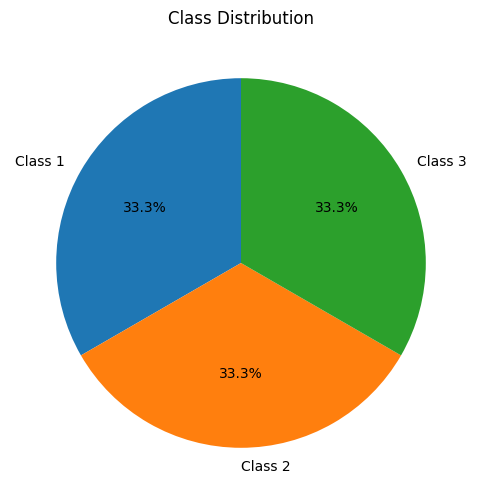

In [16]:
class_counts=df["Class (1, 2, 3)"].value_counts().sort_index()
plt.figure(figsize=(6,6))
plt.pie(class_counts,labels=["Class 1","Class 2","Class 3"],autopct="%1.1f%%",startangle=90)
plt.title("Class Distribution")
plt.show()

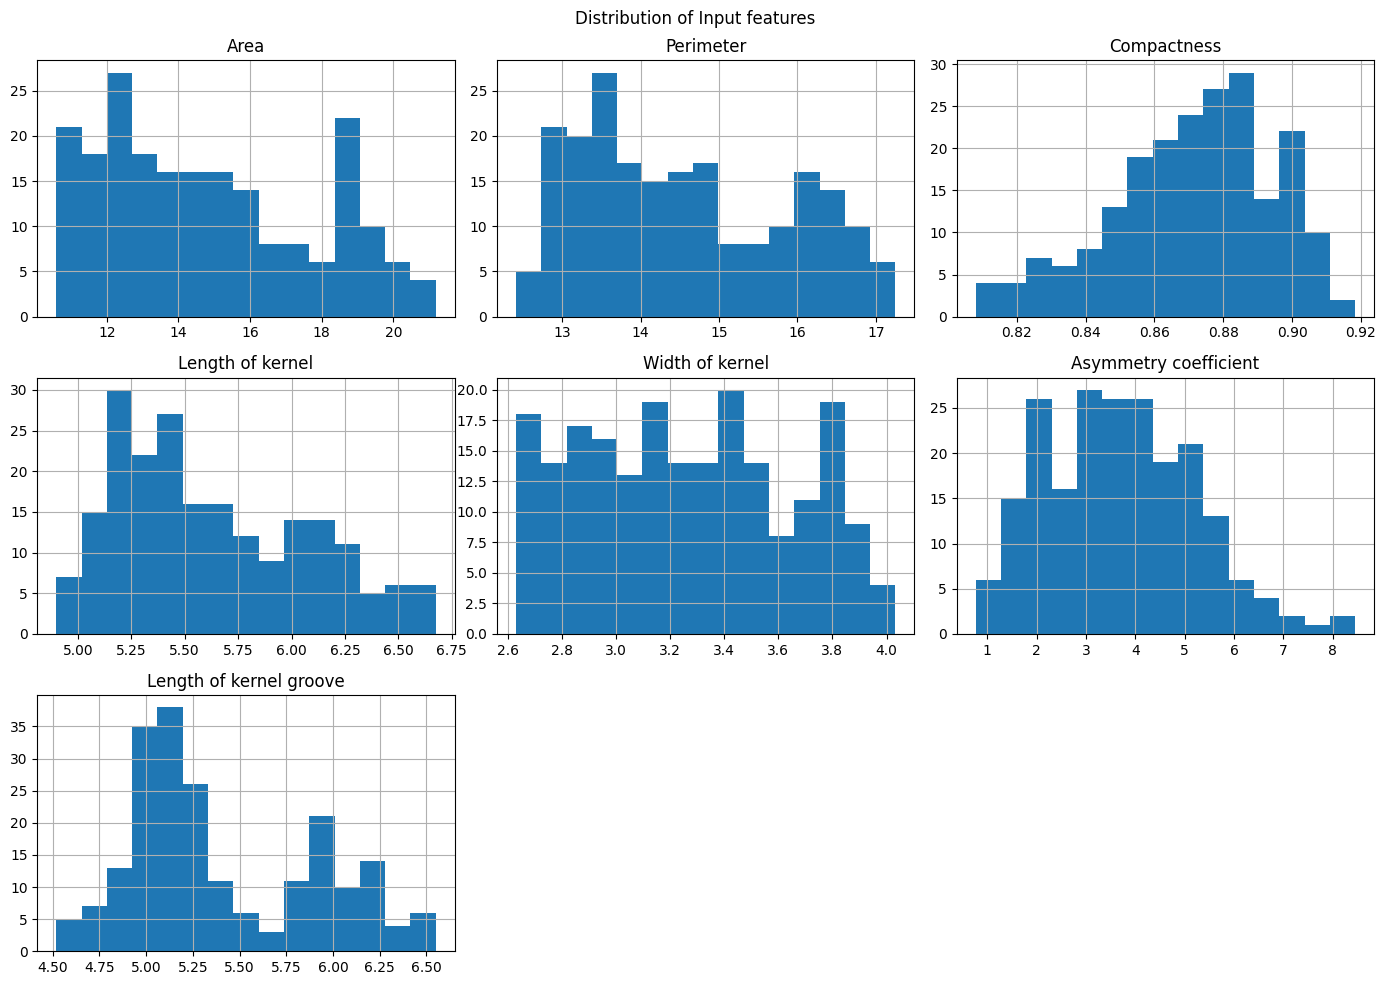

In [19]:
df.drop("Class (1, 2, 3)",axis=1).hist(figsize=(14,10),bins=15)
plt.suptitle("Distribution of Input features")
plt.tight_layout()
plt.show()

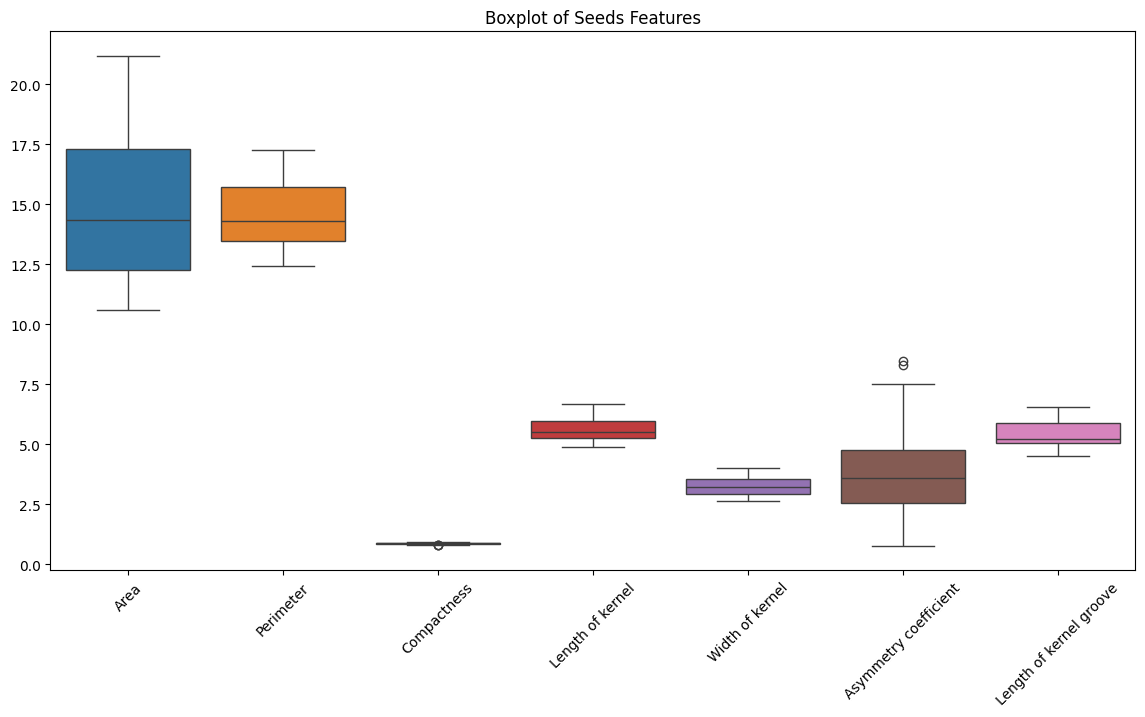

In [20]:
plt.figure(figsize=(14,7))
sns.boxplot(data=df.drop("Class (1, 2, 3)",axis=1))
plt.title("Boxplot of Seeds Features")
plt.xticks(rotation=45)
plt.show()

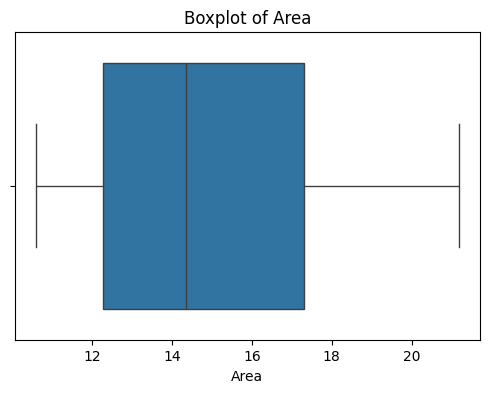

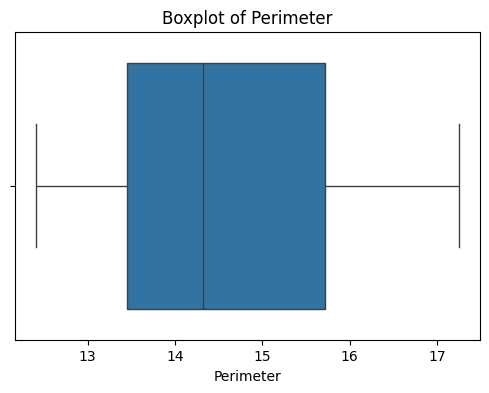

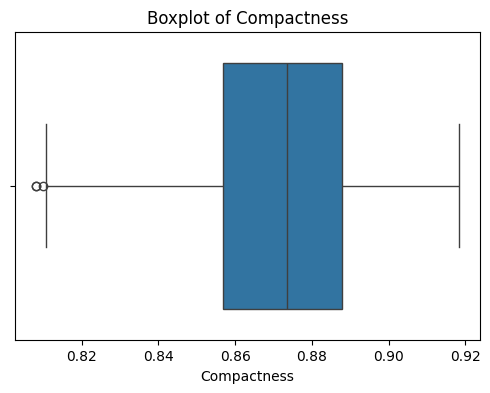

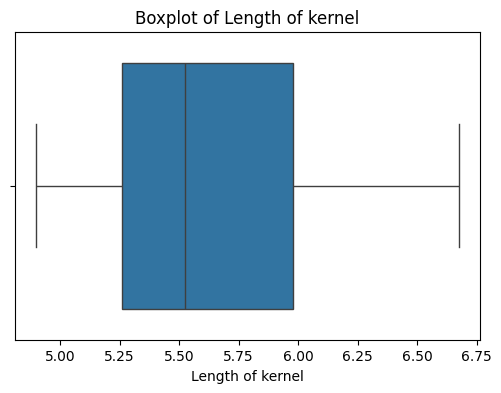

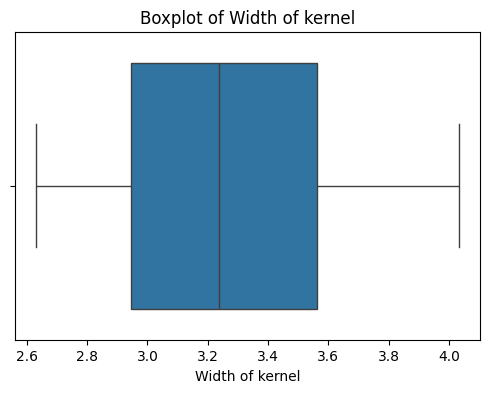

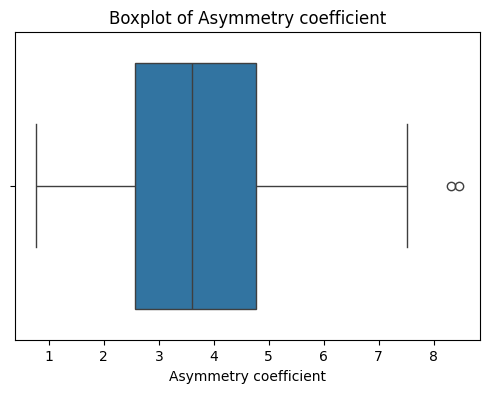

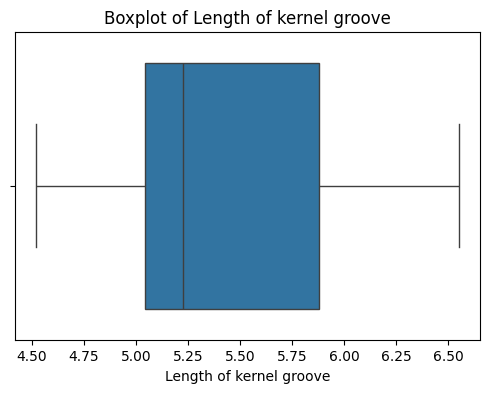

In [23]:
features = df.drop("Class (1, 2, 3)", axis=1).columns

for feature in features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[feature])

    plt.title(f"Boxplot of {feature}")
    plt.xlabel(feature)
    plt.show()


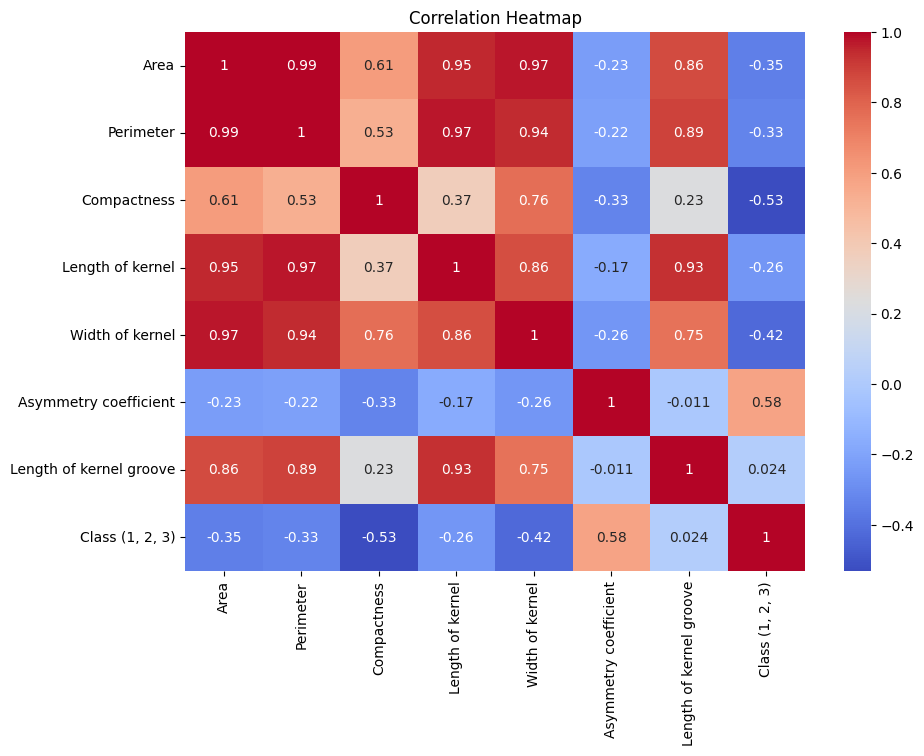

In [24]:
plt.figure(figsize=(10,7))
correlation=df.corr()
sns.heatmap(correlation,annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

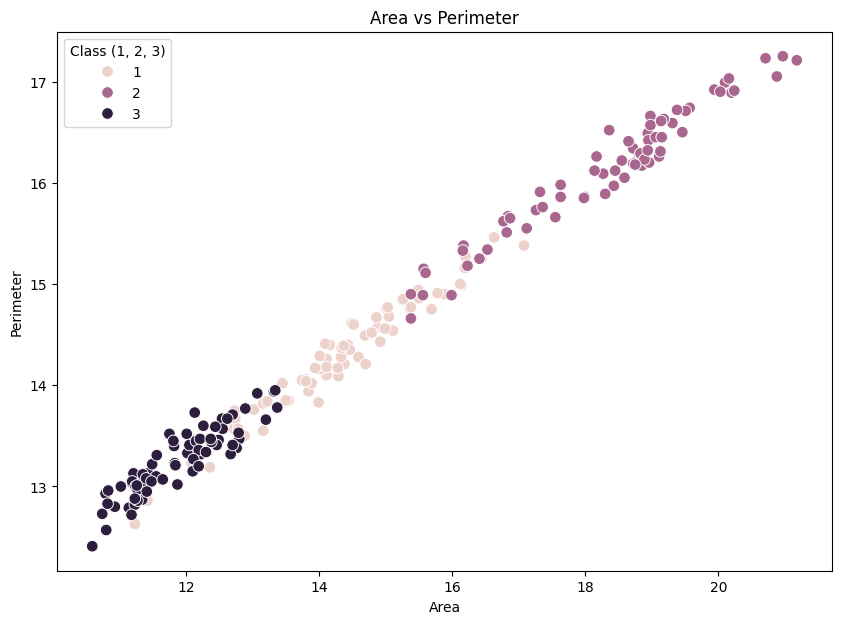

In [26]:
plt.figure(figsize=(10,7))
sns.scatterplot(data=df,x="Area",y="Perimeter",hue="Class (1, 2, 3)",s=70)
plt.title("Area vs Perimeter")
plt.show()

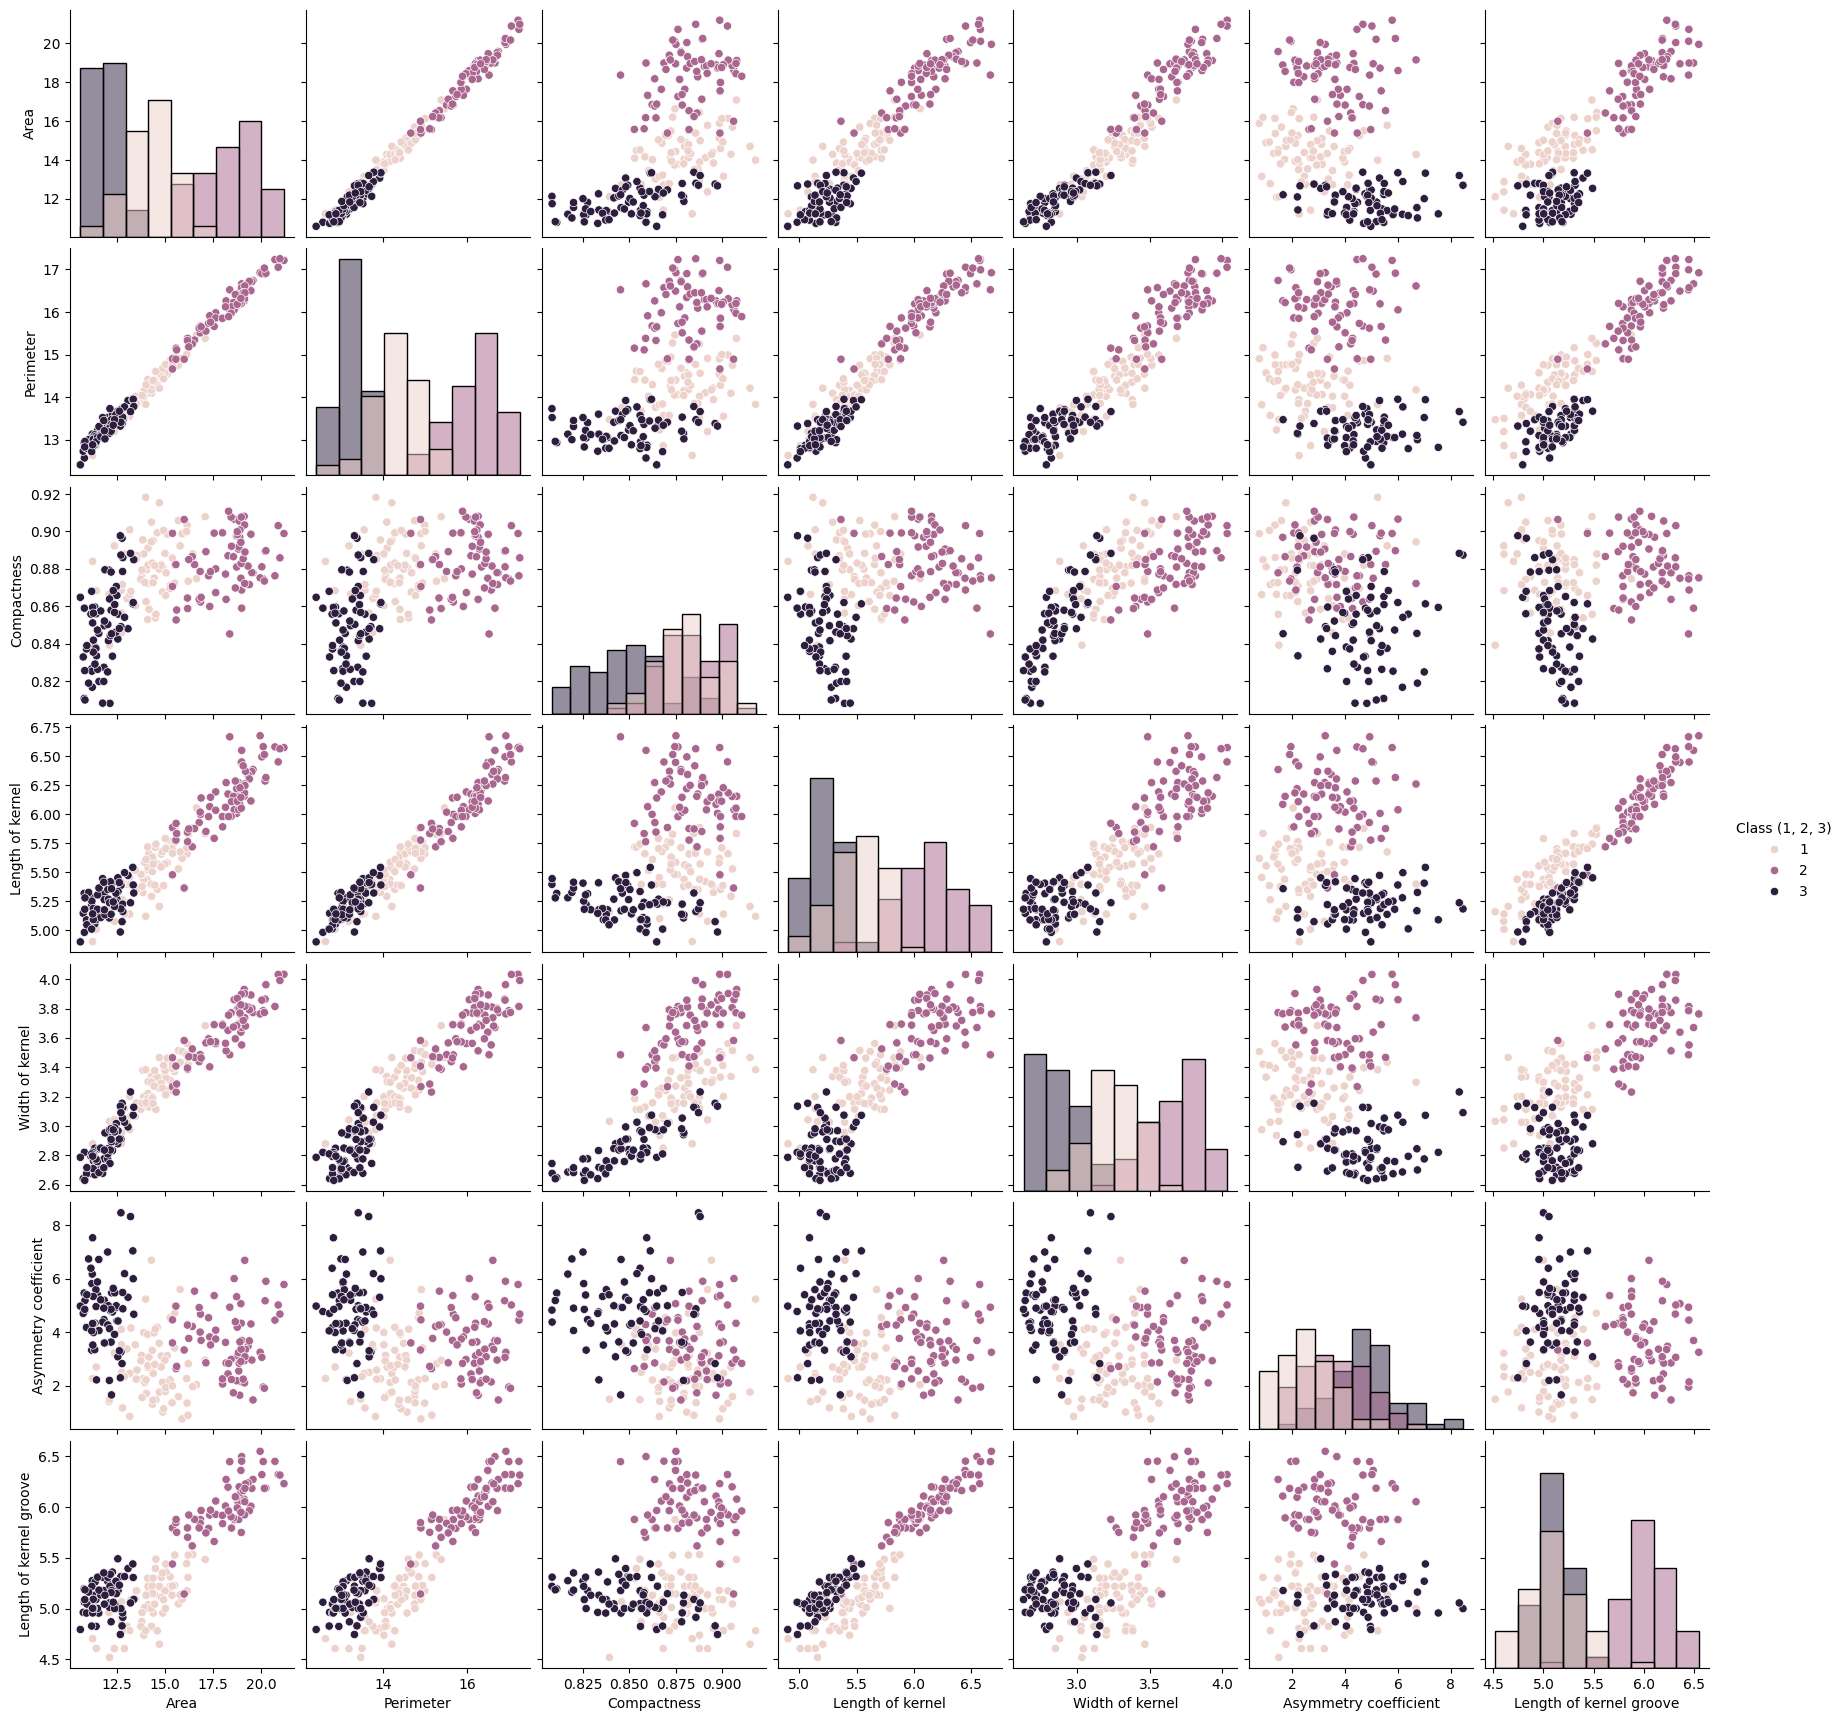

In [28]:
sns.pairplot(df,hue="Class (1, 2, 3)",diag_kind="hist")
plt.show()

In [30]:
X=df.drop("Class (1, 2, 3)",axis=1)
y_original=df["Class (1, 2, 3)"]
print("Input shape:",X.shape)
print("Output shape:",y_original.shape)


Input shape: (210, 7)
Output shape: (210,)


In [31]:
y=y_original-1
print("Original Classes:")
print(sorted(y_original.unique()))
print("\nANN encoded Classes:")
print(sorted(y.unique()))

Original Classes:
[np.int64(1), np.int64(2), np.int64(3)]

ANN encoded Classes:
[np.int64(0), np.int64(1), np.int64(2)]


In [32]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print("Training samples:",X_train.shape[0])
print("Testing samples:",X_test.shape[0])

Training samples: 168
Testing samples: 42


In [33]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [36]:
scaler.fit_transform(X_test)

array([[-0.52991291, -0.49623599, -0.27871655, -0.28725548, -0.68950684,
        -1.89773913, -0.63786437],
       [-1.17566801, -1.13903806, -1.3157494 , -1.08016108, -1.23712694,
         0.29497821, -0.74893692],
       [ 1.63968755,  1.68929104,  0.22486319,  1.68850928,  1.44414504,
        -0.56016822,  1.60143767],
       [-0.66658066, -0.82898059,  1.01010617, -1.11265721, -0.22454638,
        -0.64523847, -1.08612146],
       [-1.12441761, -1.22222421, -0.18909643, -1.25347378, -1.01239605,
        -0.7264996 , -1.52842824],
       [-1.20300156, -1.07853904, -2.02417513, -0.72920286, -1.46444094,
         1.24979649, -0.3145639 ],
       [-0.31124452, -0.32986369,  0.28460994, -0.45623536, -0.22454638,
        -1.45023154, -0.82629102],
       [-0.8613322 , -0.84410535, -0.63292941, -0.75086695, -0.85999234,
         0.64287742, -0.43555364],
       [ 0.5907626 ,  0.58518396,  0.65162568,  0.64430027,  0.6795434 ,
        -1.19057684,  0.30823578],
       [-0.65633058, -0.7155

In [37]:
print("First 5 scaled training samples:")
print(X_train_scaled[:5])

First 5 scaled training samples:
[[-1.05385596 -1.04083248 -0.88880831 -0.86174582 -1.13018592  1.03548208
  -0.22342116]
 [ 1.52927104  1.5495697   0.46355711  1.60878046  1.46287997 -0.1265987
   1.69031688]
 [-0.86392015 -0.87893234 -0.40975723 -0.96258363 -0.73186961  1.222849
  -0.76198116]
 [-0.17669786 -0.14652697  0.0862514  -0.16046471 -0.29345435 -1.48822186
  -0.23781017]
 [-1.2230715  -1.31837557 -0.4648693  -1.34301718 -1.10612655 -0.21453263
  -0.84831521]]


In [41]:
model=Sequential([
    Input(shape=(7,)),
    Dense(16,activation="relu"),
    Dense(8,activation="relu"),
    Dense(3,activation="softmax")
])

In [42]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 291 (1.14 KB)

 Trainable params: 291 (1.14 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
model.compile(
    optimizer=Adam(learning_rate=0.001),loss="sparse_categorical_crossentropy",metrics=["accuracy"]
)


In [44]:
loss="sparse_categorica_crossentropy"

In [46]:
early_stop=EarlyStopping(monitor="val_loss",patience=10,restore_best_weights=True)

In [50]:
history=model.fit(
    X_train_scaled,y_train,epochs=150,batch_size=16,validation_split=0.20,callbacks=[early_stop],verbose=1
)

Epoch 1/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9776 - loss: 0.1032 - val_accuracy: 0.9412 - val_loss: 0.1059
Epoch 2/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9776 - loss: 0.1021 - val_accuracy: 0.9412 - val_loss: 0.1033
Epoch 3/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9776 - loss: 0.1002 - val_accuracy: 0.9412 - val_loss: 0.1017
Epoch 4/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9851 - loss: 0.0994 - val_accuracy: 0.9412 - val_loss: 0.0998
Epoch 5/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9851 - loss: 0.0978 - val_accuracy: 0.9412 - val_loss: 0.0981
Epoch 6/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9851 - loss: 0.0966 - val_accuracy: 0.9412 - val_loss: 0.0984
Epoch 7/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9851 - loss: 0.0963 - val_accuracy: 0.9412 - val_loss: 0.1002
Epoch 8/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9851 - loss: 0.0944 - val_accuracy: 0.9412 - val_loss:

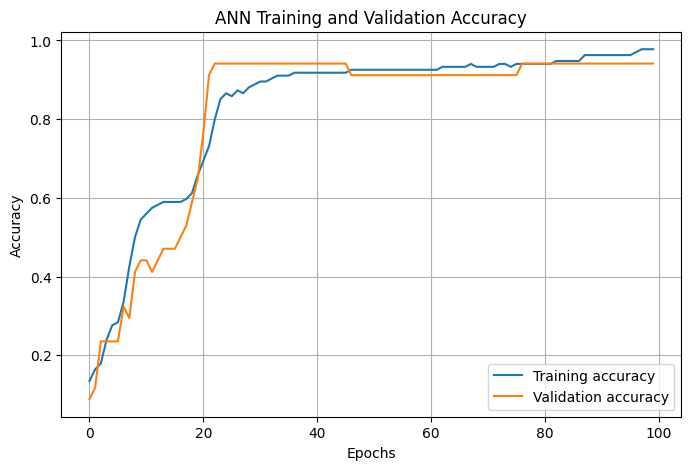

In [49]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"],label="Training accuracy")
plt.plot(history.history["val_accuracy"],label="Validation accuracy")
plt.title("ANN Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

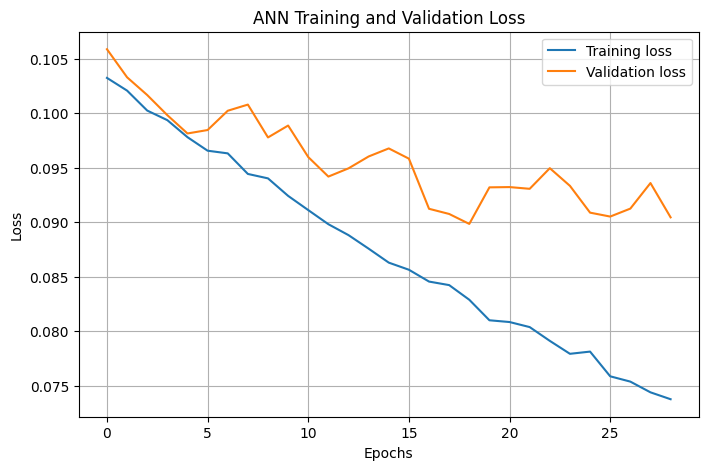

In [51]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"],label="Training loss")
plt.plot(history.history["val_loss"],label="Validation loss")
plt.title("ANN Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [53]:
test_loss,test_accuracy=model.evaluate(X_test_scaled,y_test)

print("Test Loss:",test_loss)
print("Test Accuracy:",test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9286 - loss: 0.1777
Test Loss: 0.17767848074436188
Test Accuracy: 0.9285714030265808


In [55]:
y_prob=model.predict(X_test_scaled,verbose=1)
print(y_prob[:5])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step
[[9.9831992e-01 4.9106908e-05 1.6308434e-03]
 [2.0030204e-03 3.7077160e-05 9.9795973e-01]
 [1.3956848e-03 9.9854463e-01 5.9645779e-05]
 [8.0560863e-01 2.0824608e-03 1.9230893e-01]
 [5.2978188e-01 5.4392196e-05 4.7016376e-01]]


In [56]:
y_pred=np.argmax(y_prob,axis=1)
print("Predicted encoded classes:")
print(y_pred[:10])


Predicted encoded classes:
[0 2 1 0 0 2 0 2 0 2]


In [57]:
y_pred_original=y_pred+1
y_test_original=y_test+1
print("Predicted classes:")
print(y_pred_original[:10])

Predicted classes:
[1 3 2 1 1 3 1 3 1 3]


In [59]:
comparision=pd.DataFrame({"Actual":y_test_original,"Predicted Class":y_pred_original})
comparision.head(15)

,Actual,Predicted Class
30,1,1
172,3,3
84,2,2
199,3,1
60,1,1
155,3,3
45,1,1
182,3,3
9,1,1
196,3,3
